继续演示条件分支
# 同时路由至多个节点
就是有条件判断，符合条件A，同时执行左边的两个节点， 符合条件B，同时执行右边的两个节点

上面场景，使用path_map和不使用path_map就会出现区别

{'topic': '猫咪', 'poem': '## 《猫之书》\n\n夜被窗棂裁成纱，\n你端坐成“无数次被驯养”的注脚。\n你是无言的完整，却允许梳子\n游走成波浪，在皮毛间撰写晨昏。\n\n未完成的釉色在瞳仁里烧制，\n镜中戏耍的线团，映出\n捕风者的舞蹈。我欲拆解那步态，\n你却将利爪收成句点，附上光丝的跋。\n\n指腹沿脊背犁开两亩寂静，\n你的呼噜卷起静止的万花筒。\n那眼窥视过万千个窗台的野兽，\n在你弓臂弯折时，藏起踪迹。\n\n此刻晚霞舔舐你的眉睫，\n你蓬起的微光的磷粉，\n便把楼群的骨架，\n酿成湛蓝水域。', 'ci_poem': '好的，这首词以猫咪为主题，融入了古典意象，既有猫咪的慵懒可爱，也有神秘灵性。\n\n**《踏莎行·狸奴》**\n\n**雪爪攀帘，银须探月，**\n**金瞳暗转琉璃色。**\n**昼眠花影卧琼枝，**\n**夜巡书案摹梅叶。**\n\n**捕影何须，惊鸿一瞥，**\n**鼠姑阶下踪难灭。***\n**忽闻瓦上踏清商，**\n**一痕春信随风没。**\n\n***\n\n**【注释】**\n*   **狸奴**：古人对猫的雅称。\n*   **雪爪、银须**：形容白猫的爪子与胡须。\n*   **金瞳**：猫在暗处发光的眼睛。\n*   **摹梅叶**：猫咪在书案上走过留下的脚印，像散落的梅花瓣。\n*   **鼠姑**：牡丹的别名，此处指代庭院花草，暗示猫护花驱鼠的职责。\n\n***\n\n**【赏析】**\n上阕写静态与习性：白昼蜷卧花荫，夜晚精灵般巡视，金瞳如琉璃闪烁。下阕写动态与神韵：捕鼠时如惊鸿，跃上屋瓦时发出踏乐的声响，最后一缕春意（或暗喻神秘踪迹）随风消散。全词以细腻笔触勾勒出猫的优雅、灵动与难以捉摸的灵气。', 'content_type': '诗'}
-----------------
{'topic': '猫咪', 'joke': '一只猫走进一家咖啡馆，跳上吧台，用爪子敲了敲菜单，冲着店员“喵”了一声。  \n店员笑着摇摇头：“抱歉，我们不招待猫。”  \n猫没说话，掏出一张信用卡拍在吧台上。店员愣住了，递上一杯拿铁。猫喝了一口，又“喵”了一声，然后转身要走。  \n店员追上去喊：“等等！你还没付小费呢！”  \n\n猫回头，淡定地舔了舔爪子：  \n**“你以为我每天挠沙发、抓窗帘，是在

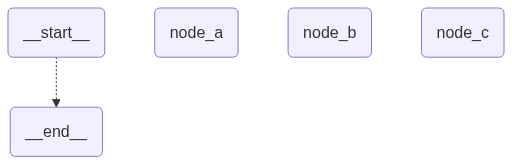

In [4]:
# 不使用path_map
# 例子，先写使用path_map，等下再写不写path_map

from dotenv import load_dotenv
load_dotenv(override=True) # 如果有其他名称， 去覆盖
from langchain_deepseek import ChatDeepSeek
from typing import TypedDict,Annotated,Literal, Sequence
from langgraph.graph import StateGraph,START,END
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem: str # 词，另外一种形式
    content_type: str

# 2. 定义节点
def node_a(state:OverAllState) -> OverAllState:
    poem = model.invoke(f"写一首关于{state['topic']}主题的诗").content
    return {
        "poem": poem
    }

def node_b(state:OverAllState) -> OverAllState:
    joke = model.invoke(f"写一个关于{state['topic']}的笑话").content
    return {
        "joke": joke
    }

def node_c(state:OverAllState) -> OverAllState:
    ci_poem = model.invoke(f"写一个关于{state['topic']}的词").content
    return {
        "ci_poem": ci_poem
    }

def my_route(state: OverAllState) -> Sequence[Literal["node_a", "node_b", "node_c"]]:
    if "诗" in state["content_type"]:
        return ["node_a", "node_c"]
    else:
        return ["node_b", "node_c"]


# 3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_node(node_c)


# 改成并行
builder.add_conditional_edges(START, my_route) # 没有添加path_map
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()
poem_res = graph.invoke({"topic":"猫咪","content_type":"诗"})
print(poem_res)

print("-----------------")

joke_res = graph.invoke({"topic":"猫咪","content_type":"笑话"})
print(joke_res)

display(graph)

# 流程没有问题， 会去执行ac或者bc，  但是流程图有问题
# 路由多个节点，没有办法很好的识别，路由单个节点，可以自己解决
